TASK 1: Load Dataset + EDA

(205, 26)

Data Types:
symboling              int64
normalized-losses     object
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                  object
stroke                object
compression-ratio    float64
horsepower            object
peak-rpm              object
city-mpg               int64
highway-mpg            int64
price                 object
dtype: object

Missing Values:
normalized-losses    41
num-of-doors          2
bore                  4
stroke                4
horsepower            2
peak-rpm              2
price                 4
dtype: int64

Unique Val

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,164.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,201.000000,201.000000,205.000000,203.000000,203.000000,205.000000,205.000000,201.000000
mean,0.834146,122.000000,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329751,3.255423,10.142537,104.256158,5125.369458,25.219512,30.751220,13207.129353
std,1.245307,35.442168,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.273539,0.316717,3.972040,39.714369,479.334560,6.542142,6.886443,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000



Mean:


symboling                0.834146
normalized-losses      122.000000
wheel-base              98.756585
length                 174.049268
width                   65.907805
height                  53.724878
curb-weight           2555.565854
engine-size            126.907317
bore                     3.329751
stroke                   3.255423
compression-ratio       10.142537
horsepower             104.256158
peak-rpm              5125.369458
city-mpg                25.219512
highway-mpg             30.751220
price                13207.129353
dtype: float64


Median:


symboling                1.00
normalized-losses      115.00
wheel-base              97.00
length                 173.20
width                   65.50
height                  54.10
curb-weight           2414.00
engine-size            120.00
bore                     3.31
stroke                   3.29
compression-ratio        9.00
horsepower              95.00
peak-rpm              5200.00
city-mpg                24.00
highway-mpg             30.00
price                10295.00
dtype: float64


Standard Deviation:


symboling               1.245307
normalized-losses      35.442168
wheel-base              6.021776
length                 12.337289
width                   2.145204
height                  2.443522
curb-weight           520.680204
engine-size            41.642693
bore                    0.273539
stroke                  0.316717
compression-ratio       3.972040
horsepower             39.714369
peak-rpm              479.334560
city-mpg                6.542142
highway-mpg             6.886443
price                7947.066342
dtype: float64

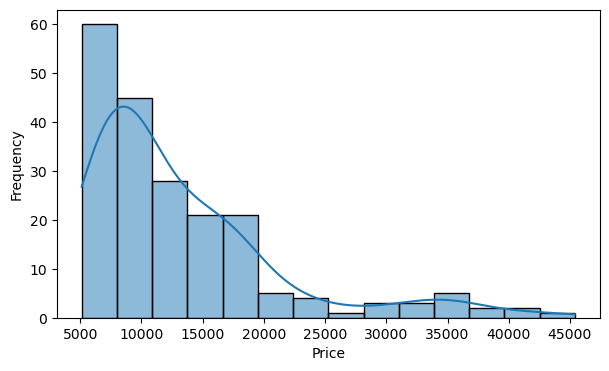

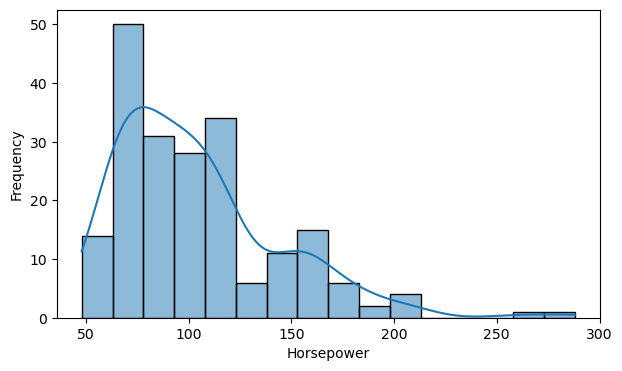

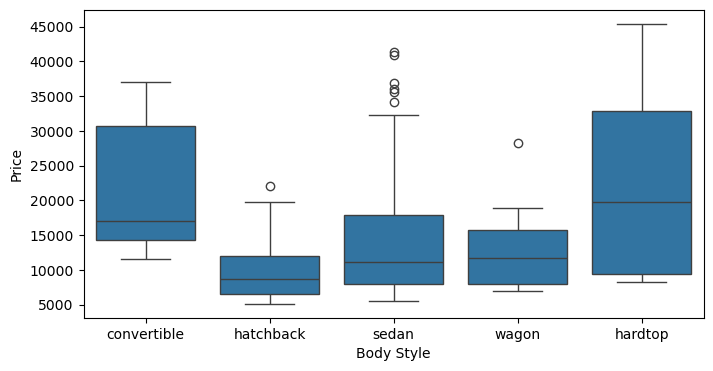

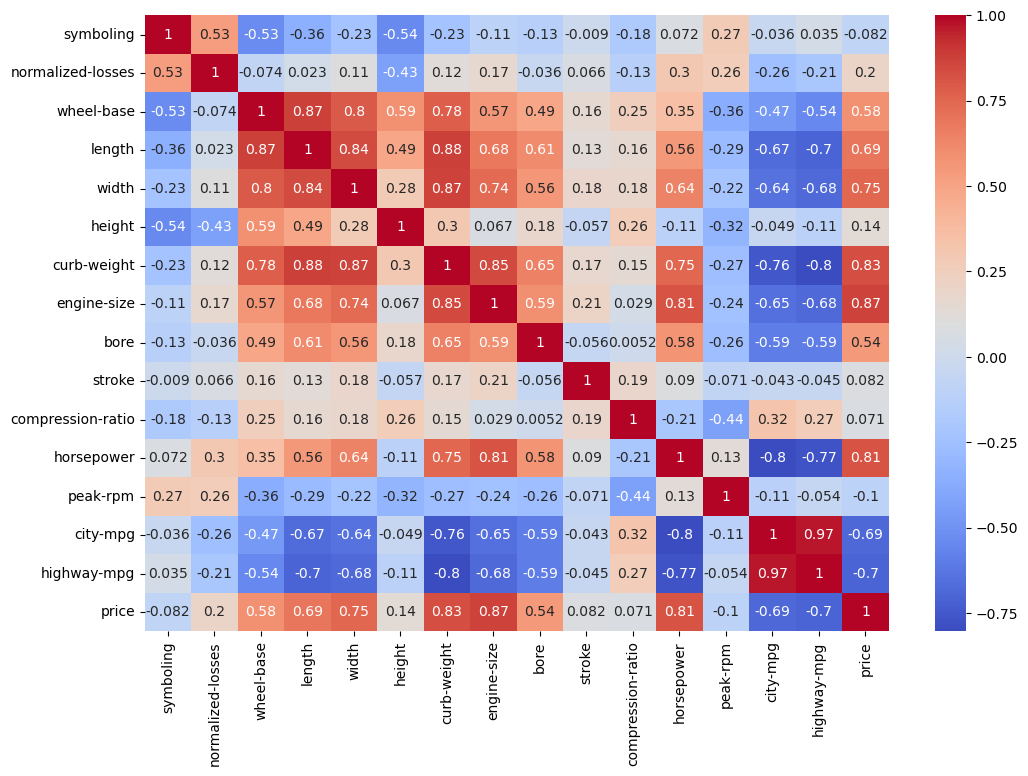

In [61]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


import pandas as pd

headers = ["symboling","normalized-losses","make","fuel-type","aspiration","num-of-doors",
           "body-style","drive-wheels","engine-location","wheel-base","length","width",
           "height","curb-weight","engine-type","num-of-cylinders","engine-size",
           "fuel-system","bore","stroke","compression-ratio","horsepower","peak-rpm",
           "city-mpg","highway-mpg","price"]

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/auto.csv"

df = pd.read_csv(url, names=headers)

print(df.shape)
df.head()


df.replace("?", np.nan, inplace=True)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nUnique Values in Categorical Columns:")
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    print(col, ":", df[col].dropna().unique())


numeric_cols = ["normalized-losses","bore","stroke","horsepower","peak-rpm","price"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nDescriptive Statistics:")
display(df.describe())

print("\nMean:")
display(df.select_dtypes(include=np.number).mean())

print("\nMedian:")
display(df.select_dtypes(include=np.number).median())

print("\nStandard Deviation:")
display(df.select_dtypes(include=np.number).std())


plt.figure(figsize=(7,4))
sns.histplot(df["price"], kde=True)
#plt.title("Figure 1: Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(7,4))
sns.histplot(df["horsepower"], kde=True)
#plt.title("Figure 2: Distribution of Horsepower")
plt.xlabel("Horsepower")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="body-style", y="price")
#plt.title("Figure 3: Price Distribution by Body Style")
plt.xlabel("Body Style")
plt.ylabel("Price")
plt.show()


plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
#plt.title("Figure 4: Correlation Heatmap of Numerical Features")
plt.show()

TASK 2: Data Cleaning + Feature Engineering

In [62]:


num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum().sum())


df["price"] = df["price"].astype(float)
df["horsepower"] = df["horsepower"].astype(float)


df["city-L/100km"] = 235 / df["city-mpg"]


bins = np.linspace(df["horsepower"].min(), df["horsepower"].max(), 4)
labels = ["Low", "Medium", "High"]
df["horsepower-binned"] = pd.cut(df["horsepower"], bins=bins, labels=labels, include_lowest=True)

print("\nHorsepower Bins:")
print(df["horsepower-binned"].value_counts())


df["length-normalized"] = df["length"] / df["length"].max()

display(df[["horsepower","horsepower-binned","city-mpg","city-L/100km","length","length-normalized"]].head())

Missing values after cleaning:
0

Horsepower Bins:
horsepower-binned
Low       163
Medium     40
High        2
Name: count, dtype: int64


,horsepower,horsepower-binned,city-mpg,city-L/100km,length,length-normalized
0,111.0,Low,21,11.190476,168.8,0.811148
1,111.0,Low,21,11.190476,168.8,0.811148
2,154.0,Medium,19,12.368421,171.2,0.822681
3,102.0,Low,24,9.791667,176.6,0.848630
4,115.0,Low,18,13.055556,176.6,0.848630


TASK 3: Regression Models

In [63]:


features = ["horsepower","engine-size","curb-weight","width","city-L/100km","highway-mpg"]
X = df[features]
y = df["price"]

def regression_experiment(test_size):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )


    lr = LinearRegression()
    lr.fit(X_train, y_train)
    lr_pred = lr.predict(X_test)


    rf = RandomForestRegressor(n_estimators=200, random_state=42)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)

    results = pd.DataFrame({
        "Split": [f"{int((1-test_size)*100)}/{int(test_size*100)}"]*2,
        "Model": ["Linear Regression", "Random Forest"],
        "R2 Score": [r2_score(y_test, lr_pred), r2_score(y_test, rf_pred)],
        "MAE": [mean_absolute_error(y_test, lr_pred), mean_absolute_error(y_test, rf_pred)],
        "MSE": [mean_squared_error(y_test, lr_pred), mean_squared_error(y_test, rf_pred)],
        "RMSE": [np.sqrt(mean_squared_error(y_test, lr_pred)), np.sqrt(mean_squared_error(y_test, rf_pred))]
    })

    return results, y_test, lr_pred, rf_pred, rf

results_80, y_test_80, lr_pred_80, rf_pred_80, rf_model = regression_experiment(0.20)
results_70, y_test_70, lr_pred_70, rf_pred_70, rf_model_70 = regression_experiment(0.30)

regression_results = pd.concat([results_80, results_70], ignore_index=True)
display(regression_results)

,Split,Model,R2 Score,MAE,MSE,RMSE
0,80/20,Linear Regression,0.792643,2711.436158,1.616805e+07,4020.951498
1,80/20,Random Forest,0.932110,1504.059441,5.293500e+06,2300.760775
2,70/30,Linear Regression,0.750180,2698.166649,1.714656e+07,4140.840259
3,70/30,Random Forest,0.892773,1718.962862,7.359613e+06,2712.860599


 TASK 4: Classification Model

Classification Accuracy: 0.8048780487804879

Classification Report:
              precision    recall  f1-score   support

        High       0.83      0.71      0.77        14
         Low       0.93      0.93      0.93        14
      Medium       0.67      0.77      0.71        13

    accuracy                           0.80        41
   macro avg       0.81      0.80      0.80        41
weighted avg       0.81      0.80      0.81        41



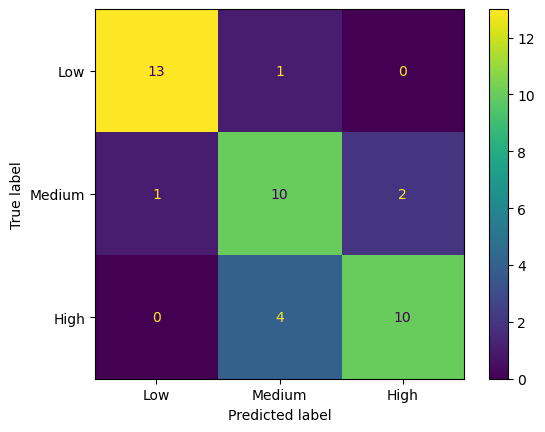

In [64]:


df["price-category"] = pd.qcut(df["price"], 3, labels=["Low","Medium","High"])

X_class = df[features]
y_class = df["price-category"]

scaler = StandardScaler()
X_class_scaled = scaler.fit_transform(X_class)

X_train, X_test, y_train, y_test = train_test_split(
    X_class_scaled, y_class, test_size=0.20, random_state=42, stratify=y_class
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Classification Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=["Low","Medium","High"])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low","Medium","High"])
disp.plot()
#plt.title("Figure 5: Confusion Matrix for Price Category Classification")
plt.show()

 TASK 5: Actual vs Predicted Plot

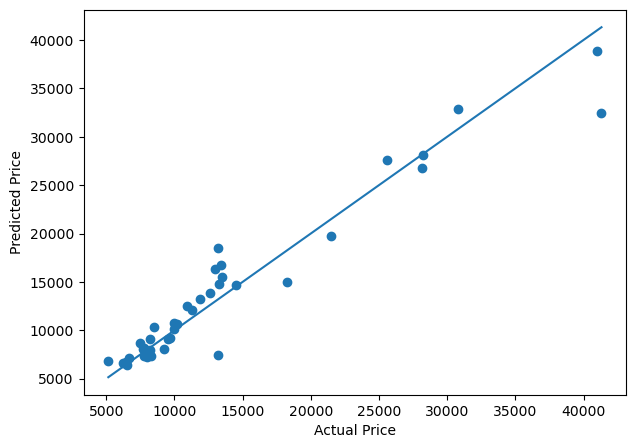

,Feature,Importance
1,engine-size,0.465800
2,curb-weight,0.364746
5,highway-mpg,0.068812
0,horsepower,0.047650
3,width,0.039846
4,city-L/100km,0.013145


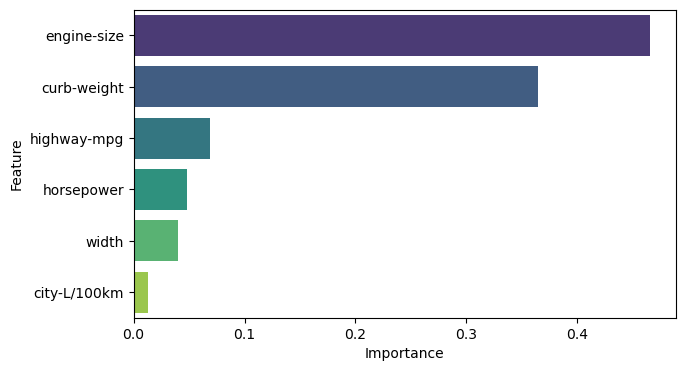

In [65]:


plt.figure(figsize=(7,5))
plt.scatter(y_test_80, rf_pred_80)
plt.plot([y_test_80.min(), y_test_80.max()], [y_test_80.min(), y_test_80.max()])
#plt.title("Figure 6: Actual vs Predicted Car Prices - Random Forest")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

# Feature Importance from Random Forest
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(importance)

plt.figure(figsize=(7,4))
sns.barplot(data=importance, x="Importance", y="Feature", hue="Feature", palette='viridis', legend=False)
#plt.title("Figure 7: Feature Importance for Car Price Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Task 6: Business Insights

In [66]:


print("Top Price Influencing Features:")
display(importance)

print("""
Business Insights:
1. Cars with larger engine size, greater curb weight and higher horsepower generally have higher prices.
2. Fuel efficiency also matters because lower mpg and higher city-L/100km often indicate larger and more powerful cars.
3. Manufacturers should focus on engine performance, vehicle size, body design and fuel efficiency when positioning cars in different price segments.
4. Customers can use this model to estimate whether a car price is reasonable based on its technical features.
""")

Top Price Influencing Features:


,Feature,Importance
1,engine-size,0.465800
2,curb-weight,0.364746
5,highway-mpg,0.068812
0,horsepower,0.047650
3,width,0.039846
4,city-L/100km,0.013145



Business Insights:
1. Cars with larger engine size, greater curb weight and higher horsepower generally have higher prices.
2. Fuel efficiency also matters because lower mpg and higher city-L/100km often indicate larger and more powerful cars.
3. Manufacturers should focus on engine performance, vehicle size, body design and fuel efficiency when positioning cars in different price segments.
4. Customers can use this model to estimate whether a car price is reasonable based on its technical features.

